# **Data Loading and Cleaning** # 

**Loading the raw data**  
The sessions sheet was loaded from the provided Excel workbook, containing 294,024 individual EV charging session records. The raw file is not modified. All the cleaning is done on data loaded into memory, keeping the original source intact and the process reproducible.

In [1]:
import pandas as pd 
sessions = pd.read_excel('/kaggle/input/datasets/sanyazuberi/ev-charging-raw-dataset/Copy of ev_charging_dataset.xlsx', sheet_name='sessions')

sessions['start_timestamp'] = pd.to_datetime(sessions['start_timestamp'])

**Initial inspection**  
Before any cleaning, the shape, structure, and first few rows of the data were checked to confirm correct loading and expected dimensions (15 columns, ∼294k rows).

In [2]:
sessions.shape

(294024, 15)

In [3]:
sessions.head()

,session_id,station_id,charger_id,charger_type,start_timestamp,end_timestamp,session_duration_minutes,energy_kwh,price_per_kwh,total_cost,payment_method,user_type,customer_id,station_region,year
0,S_00000001,STN_001,STN_001_CH_02,DC_150kW,2022-01-01 08:30:00,2022-01-01 08:56:00,26,56.9,0.47,26.74,app,fleet,CUST_00134,North West,2022
1,S_00000002,STN_001,STN_001_CH_02,DC_150kW,2022-01-01 09:20:00,2022-01-01 09:41:00,21,40.7,0.46,18.72,app,delivery,CUST_00195,North West,2022
2,S_00000003,STN_001,STN_001_CH_04,DC_50kW,2022-01-01 09:00:00,2022-01-01 09:48:00,48,30.9,0.47,14.52,rfid,public,CUST_01935,North West,2022
3,S_00000004,STN_001,STN_001_CH_01,DC_50kW,2022-01-01 23:20:00,2022-01-02 00:01:00,41,28.4,0.45,12.78,rfid,public,CUST_00036,North West,2022
4,S_00000005,STN_001,STN_001_CH_01,DC_50kW,2022-01-01 16:10:00,2022-01-01 17:00:00,50,31.7,0.56,17.75,rfid,taxi,CUST_00011,North West,2022


In [4]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294024 entries, 0 to 294023
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   session_id                294024 non-null  object        
 1   station_id                294024 non-null  object        
 2   charger_id                294024 non-null  object        
 3   charger_type              294024 non-null  object        
 4   start_timestamp           294024 non-null  datetime64[ns]
 5   end_timestamp             294024 non-null  datetime64[ns]
 6   session_duration_minutes  294024 non-null  int64         
 7   energy_kwh                294024 non-null  float64       
 8   price_per_kwh             294024 non-null  float64       
 9   total_cost                294024 non-null  float64       
 10  payment_method            294024 non-null  object        
 11  user_type                 294024 non-null  object        
 12  cu

**Checking data quality**  
The data was checked for missing values, duplicate rows, and duplicate session_ids, but none were found. The start_timestamp column was confirmed to have converted correctly to a datetime type, and numeric ranges (session duration, energy, price, cost) were sanity-checked for implausible values. All values fell within reasonable, expected ranges.


In [5]:
# Missing values check
sessions.isna().sum()

session_id                  0
station_id                  0
charger_id                  0
charger_type                0
start_timestamp             0
end_timestamp               0
session_duration_minutes    0
energy_kwh                  0
price_per_kwh               0
total_cost                  0
payment_method              0
user_type                   0
customer_id                 0
station_region              0
year                        0
dtype: int64

In [6]:
# Duplicate rows check
sessions.duplicated().sum()

np.int64(0)

In [7]:
# Duplicate session_ids check
sessions['session_id'].duplicated().sum()

np.int64(0)

In [8]:
# timestamp conversion check
sessions['start_timestamp'].dtype

dtype('<M8[ns]')

In [9]:
# Sanity-check for implausible values
sessions.describe()

,start_timestamp,end_timestamp,session_duration_minutes,energy_kwh,price_per_kwh,total_cost,year
count,294024,294024,294024.000000,294024.000000,294024.000000,294024.000000,294024.000000
mean,2023-12-06 21:39:31.539058432,2023-12-06 22:14:37.224716544,35.094761,46.964689,0.592319,27.790589,2023.430618
min,2022-01-01 01:30:00,2022-01-01 01:54:00,15.000000,21.700000,0.450000,11.450000,2022.000000
25%,2023-05-20 05:25:00,2023-05-20 06:00:15,23.000000,33.200000,0.540000,19.700000,2023.000000
50%,2024-02-13 20:25:00,2024-02-13 21:04:00,27.000000,43.300000,0.590000,24.770000,2024.000000
75%,2024-07-24 06:42:30,2024-07-24 07:06:45,49.000000,54.000000,0.640000,33.250000,2024.000000
max,2024-12-31 23:50:00,2025-01-01 00:42:00,60.000000,80.000000,0.800000,64.000000,2024.000000
std,NaN,NaN,13.779933,16.631671,0.063600,10.268567,0.722238


**Data Quality Note: installation_date**  
Investigation revealed that installation_date in the chargers sheet is inconsistent with the actual session activity. 30% of all sessions (88,466 rows) occur before their charger’s recorded installation date. This mismatch rate correlates strongly (r ≈0.78) with how late in 2022 each charger was installed, indicating a systematic data generation issue. Session data appears to have been generated across a fixed date range independent of each charger’s install date, rather than isolated bad records for a handful of chargers.

Since this task (demand forecasting) does not depend on installation_date, I chose to exclude the field from consideration rather than drop the affected sessions, because doing so would have disproportionately removed data for later-installed chargers and biased the demand series.

# **Building the Demand Time Series**

**Setting the timestamp as the index**  
To use pandas’ time-series tools, start_timestamp is set as the DataFrame’s index.


In [10]:
sessions_ts = sessions.set_index('start_timestamp')

**Aggregating to hourly and daily demands**  
Individual sessions were grouped into hourly and daily buckets. Two demand measures were built for each: session_count (how many charging events occurred relevant to staffing/capacity) and total energy delivered in kWh (relevant for energy procurement). I chose to build both, directly reflecting both use case names in the project brief rather than picking a single definition of “demand”.

In [11]:
# resampling for hourly demand
hourly_demand = sessions_ts.resample('h').agg(
    session_count = ('session_id', 'count'),
    total_energy_kwh = ('energy_kwh', 'sum')
)

In [12]:
# resampling for daily demand
daily_demand = sessions_ts.resample('D').agg(
    session_count = ('session_id', 'count'),
    total_energy_kwh = ('energy_kwh', 'sum')
)

**Checking for gaps**  
The resampled series was confirmed to have no missing time periods. Every hour and day in the full 3-year range (Jan 2022 - Dec 2024) is represented, with genuine zero-demand hours correctly recorded as 0 rather than missing.


In [13]:
print(hourly_demand.shape)

(26303, 2)


In [14]:
print(daily_demand.isna().sum())

session_count       0
total_energy_kwh    0
dtype: int64


# **Exploratory Data Analysis**

**Daily demand over the full 3-year period**

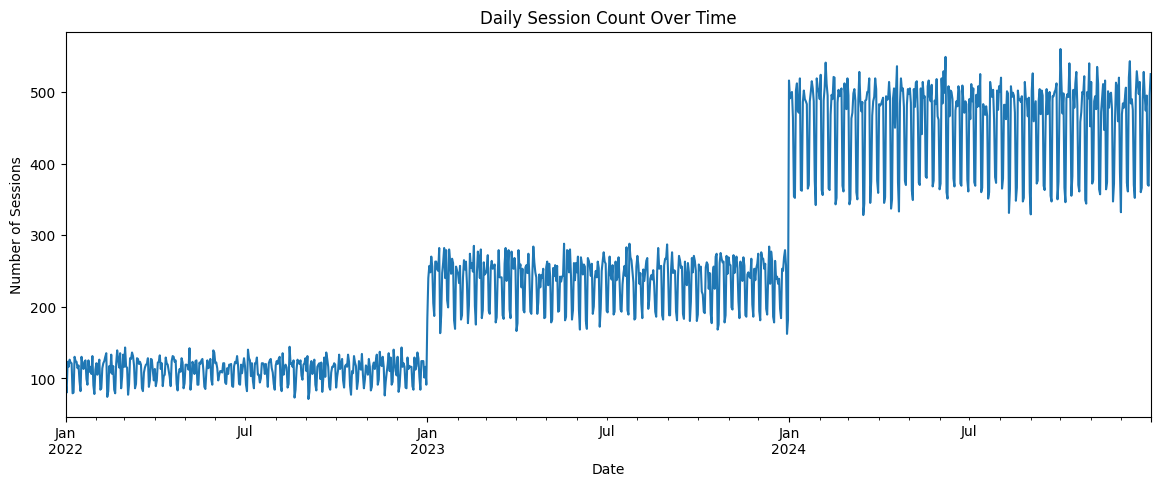

In [15]:
import matplotlib.pyplot as plt
daily_demand['session_count'].plot(figsize=(14,5), title = 'Daily Session Count Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Sessions')
plt.show()

The chart outputted above shows two sharp step-increases in daily session volume, occurring almost exactly in January 2023 and January 2024. Within each of the three resulting plateaus, demand is roughly flat with no clear internal trend. Cross-referencing against station activation dates (8 stations live in 2022, 17 by 2023, 33 by 2024) strongly suggests these jumps reflect network expansion (more stations coming online) rather than organic growth in demand per station.

**Average demand by hour of day**

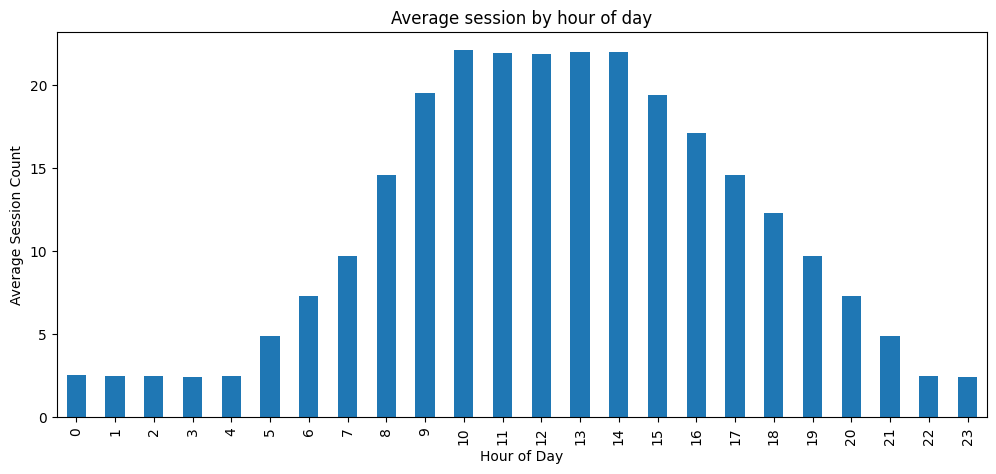

In [16]:
hourly_demand['hour'] = hourly_demand.index.hour
avg_by_hour = hourly_demand.groupby('hour')['session_count'].mean()
avg_by_hour.plot(kind = 'bar', figsize=(12,5), title = 'Average session by hour of day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Session Count')
plt.show()

Demand is near-zero overnight (00:00 - 04:00), rises sharply from 05:00, plateaus through the late morning and early afternoon (peaking around 10:00 - 14:00), and declines through the evening. This is consistent with daytime/workplace charging behaviour rather than overnight home charging.

**Average demand by day of week**

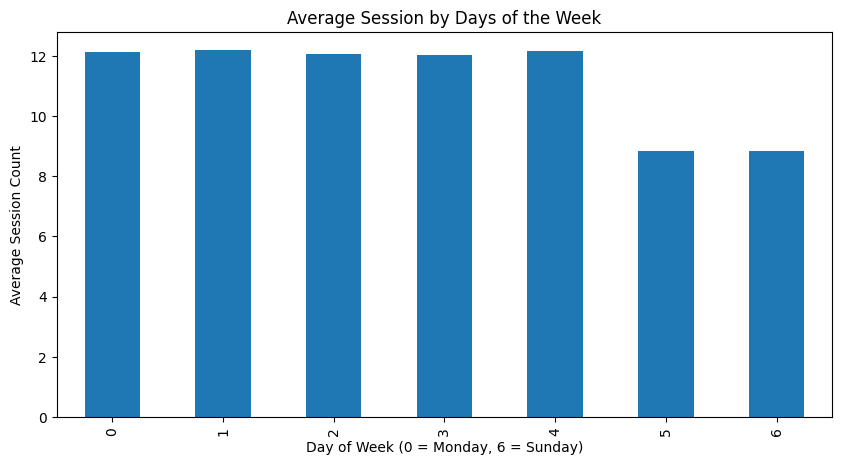

In [17]:
hourly_demand['day_of_week'] = hourly_demand.index.dayofweek
avg_by_dow = hourly_demand.groupby('day_of_week')['session_count'].mean()
avg_by_dow.plot(kind = 'bar', figsize=(10,5), title = 'Average Session by Days of the Week')
plt.xlabel('Day of Week (0 = Monday, 6 = Sunday)')
plt.ylabel('Average Session Count')
plt.show()

To check whether weekday and weekend charging behaviour differ, average demand was calculated for each day of the week using the hourly data. Weekdays (Monday - Friday) show consistently higher average demand (∼12 sessions per hourly bucket) than weekends (∼8.8), a roughly 27% drop. This pattern is consistent with the hour-of-day findings above, and together they suggest usage driven primarily by daytime, workday charging, likely commuters or workplace charging, rather than leisure or overnight home charging.

**Average demand by month**

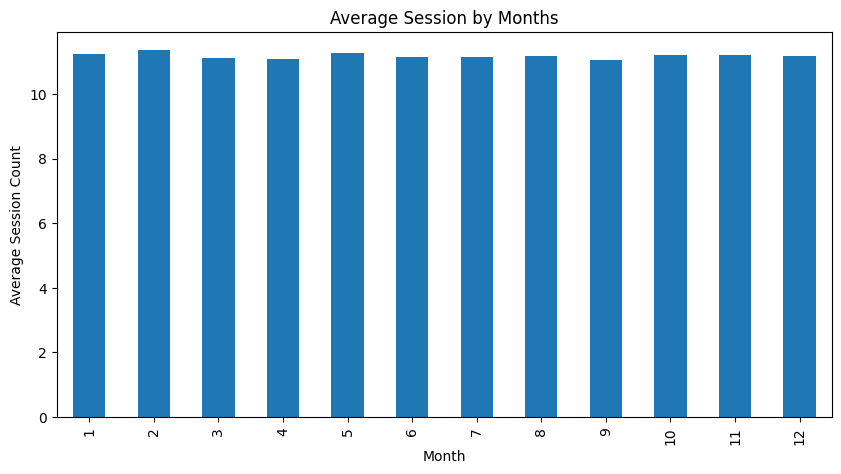

In [18]:
hourly_demand['month'] = hourly_demand.index.month
avg_by_month = hourly_demand.groupby('month')['session_count'].mean()
avg_by_month.plot(kind = 'bar', figsize=(10,5), title = 'Average Session by Months')
plt.xlabel('Month')
plt.ylabel('Average Session Count')
plt.show()

Monthly averages sit in a narrow band (11.0 - 11.4) with no clear seasonal (summer/winter) pattern. This is flatter than typically expected for real-world EV charging data and is noted as a likely characteristic of this being a synthetic or simulated dataset rather than genuine seasonal absence.

**Checking whether network growth is inflating the demand trend**

In [19]:
stations = pd.read_excel('/kaggle/input/datasets/sanyazuberi/ev-charging-raw-dataset/Copy of ev_charging_dataset.xlsx', sheet_name='stations')
stations_per_year = stations.groupby('activation_year').size().cumsum()
print(stations_per_year)

activation_year
2022     8
2023    17
2024    33
dtype: int64


Station activation counts by year (8 to 17 to 33, cumulative) were checked against the timing of the step-changes seen in the daily demand chart. The alignment is a strong indicator that raw demand growth reflects the charging network expanding, not increased usage per existing station. I have planned a per-station-normalized comparison as a follow-up to confirm this quantitatively.

In [20]:
# save output for the next notebook
hourly_demand.to_csv('/kaggle/working/hourly_demand.csv')
daily_demand.to_csv('/kaggle/working/daily_demand.csv')